## Step 0 - Setup
We just import the tools we need. `torch` is the deep learning library, `torchvision` gives us the pretrained AI model, `PIL` and `io` let us simulate JPEG compression.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import numpy as np
import io
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Step 1 - Load a pretrained image classifier
We're borrowing ResNet18, a well-known, already-trained AI model. It was trained on ImageNet (1.2 million images, 1000 categories like 'cat', 'church', 'sports car', etc). We don't train it -- we just use it as-is, as our target to fool.

In [2]:
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
model = model.to(device).eval()

# Freeze the model - we are NOT training it, only crafting a perturbation
for p in model.parameters():
    p.requires_grad = False

# ImageNet models expect input images normalized with these specific mean/std values
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def normalize(x):
    # x is expected in [0, 1] pixel range, shape (batch, 3, H, W)
    return (x - IMAGENET_MEAN) / IMAGENET_STD

print('Model loaded. Number of parameters:', sum(p.numel() for p in model.parameters()))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Model loaded. Number of parameters: 11689512


## Step 2 - Get some real test images
To MEASURE the fooling rate later, we need real photos. We'll download **Imagenette** -- a small, easy, 10-category subset of ImageNet (about 100 MB), commonly used exactly for quick experiments like this.

In [3]:
!wget -q https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
!tar -xzf imagenette2-160.tgz
print('Downloaded and extracted.')

Downloaded and extracted.


In [4]:
import glob, random

IMG_SIZE = 224  # ResNet18 expects 224x224 images

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),  # converts pixel values to [0, 1] range automatically
])

all_val_images = glob.glob('imagenette2-160/val/*/*.JPEG')
random.seed(0)
sample_paths = random.sample(all_val_images, 200)  # 200 test images is plenty for a clear result

def load_image(path):
    img = Image.open(path).convert('RGB')
    return transform(img)

test_images = torch.stack([load_image(p) for p in sample_paths]).to(device)
print('Loaded test images:', test_images.shape)

Loaded test images: torch.Size([200, 3, 224, 224])


## Step 3 - Craft the data-free universal perturbation

**The key idea, explained simply:** every AI image model processes a picture in stages (layers). Early layers detect edges, later layers detect complex shapes. If we can make these internal layers "light up" abnormally strongly using nothing but random noise as input, the resulting noise pattern tends to confuse the model on real images too -- because it's exploiting the model's internal wiring, not any specific photo's content.

We do this by:
1. Starting with a tiny random noise pattern (`delta`).
2. Feeding pure random static images (not real photos!) through the model, with `delta` added.
3. Measuring how strongly the internal layers react (their "activation energy").
4. Adjusting `delta` step by step to make that reaction as large as possible.
5. Keeping `delta` small enough that it would look like faint noise on a real photo (this is the `epsilon` limit below).

Step 0: loss = 6.199
Step 50: loss = 5.309
Step 100: loss = 5.119
Step 150: loss = 5.046
Step 200: loss = 5.035
Step 250: loss = 5.046
Done crafting the universal perturbation.


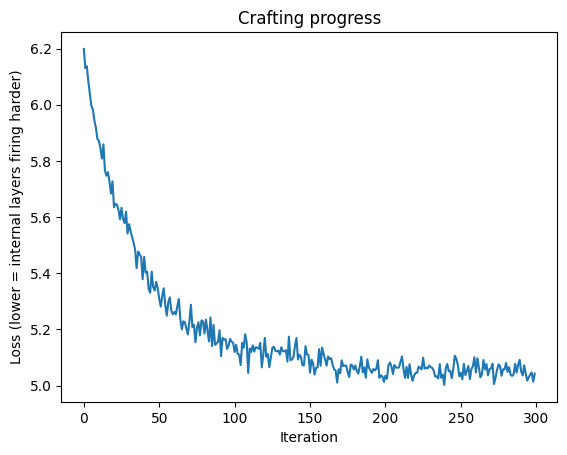

In [5]:
# How "strong" the noise pattern is allowed to be (in pixel terms, 0-1 scale).
# 10/255 is a standard, fairly subtle amount used in this line of research.
EPSILON = 10 / 255

# We'll hook into these 4 major stages of ResNet18 to read their activations
activations = {}

def get_hook(name):
    def hook(module, inp, out):
        activations[name] = out
    return hook

model.layer1.register_forward_hook(get_hook('layer1'))
model.layer2.register_forward_hook(get_hook('layer2'))
model.layer3.register_forward_hook(get_hook('layer3'))
model.layer4.register_forward_hook(get_hook('layer4'))

def activation_loss():
    # We want to MAXIMIZE the average squared activation at each layer.
    # Taking log keeps no single layer from dominating the total.
    total = 0
    for name in ['layer1', 'layer2', 'layer3', 'layer4']:
        act = activations[name]
        total = total + torch.log(torch.mean(act ** 2) + 1e-8)
    return total

# Initialize our perturbation as tiny random noise
delta = (torch.rand(1, 3, IMG_SIZE, IMG_SIZE, device=device) * 2 - 1) * EPSILON
delta.requires_grad_(True)

optimizer = torch.optim.Adam([delta], lr=0.01)

NUM_ITERATIONS = 300
BATCH_SIZE = 16

loss_history = []

for step in range(NUM_ITERATIONS):
    # Pure random static images -- this is the "data-free" part, no real photos here
    random_noise_images = torch.rand(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE, device=device)

    perturbed = torch.clamp(random_noise_images + delta, 0, 1)
    model(normalize(perturbed))  # forward pass fills in `activations` via our hooks

    loss = -activation_loss()  # negative because optimizer MINIMIZES, and we want to MAXIMIZE activations
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Keep delta within our allowed noise budget after every update
    with torch.no_grad():
        delta.clamp_(-EPSILON, EPSILON)

    loss_history.append(loss.item())
    if step % 50 == 0:
        print(f'Step {step}: loss = {loss.item():.3f}')

delta = delta.detach()
print('Done crafting the universal perturbation.')

plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss (lower = internal layers firing harder)')
plt.title('Crafting progress')
plt.show()

## Step 4 - Reproduce the core result: measure the fooling rate
Now we take our REAL test photos, get the model's original prediction for each, then add our crafted noise pattern and check: did the prediction change? The **fooling rate** is simply the percentage of images where the answer flipped.

Fooling rate: 48.0% of images changed their predicted label
(Published papers on this topic typically report 40-85% depending on model and epsilon.
Your number may be lower with fewer iterations/smaller epsilon -- that is fine, report it honestly.)


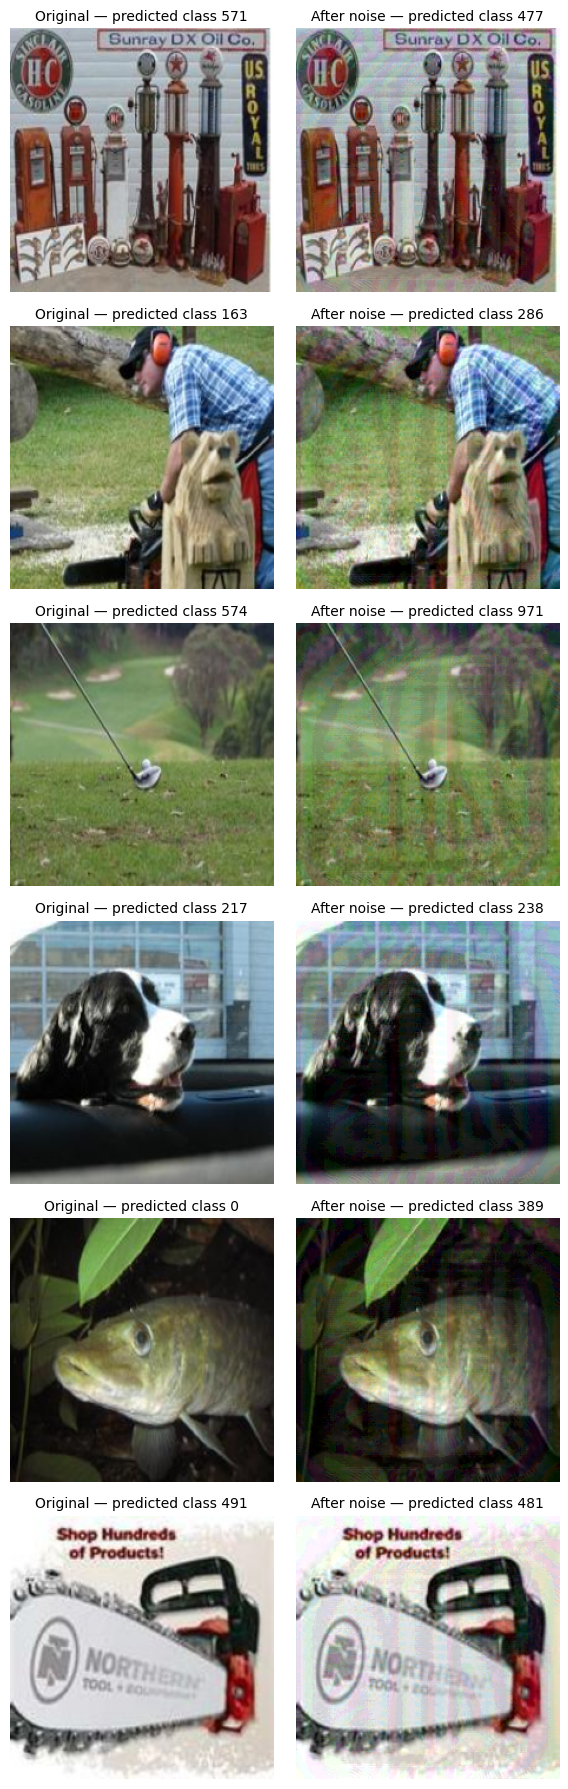

In [6]:
@torch.no_grad()
def get_predictions(images):
    logits = model(normalize(images))
    return logits.argmax(dim=1)

original_preds = get_predictions(test_images)

perturbed_test_images = torch.clamp(test_images + delta, 0, 1)
perturbed_preds = get_predictions(perturbed_test_images)

fooling_rate = (original_preds != perturbed_preds).float().mean().item() * 100
print(f'Fooling rate: {fooling_rate:.1f}% of images changed their predicted label')
print('(Published papers on this topic typically report 40-85% depending on model and epsilon.\n'
      'Your number may be lower with fewer iterations/smaller epsilon -- that is fine, report it honestly.)')
# Find several different examples where the model was actually fooled
fooled_indices = (original_preds != perturbed_preds).nonzero().squeeze().tolist()
if isinstance(fooled_indices, int):
    fooled_indices = [fooled_indices]

num_examples = 6  # change this if you want more or fewer
selected = fooled_indices[:num_examples]

fig, axes = plt.subplots(len(selected), 2, figsize=(6, 3 * len(selected)))

for row, idx in enumerate(selected):
    axes[row, 0].imshow(test_images[idx].permute(1, 2, 0).cpu().numpy())
    axes[row, 0].set_title(f'Original — predicted class {original_preds[idx].item()}', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(perturbed_test_images[idx].permute(1, 2, 0).cpu().numpy())
    axes[row, 1].set_title(f'After noise — predicted class {perturbed_preds[idx].item()}', fontsize=10)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('multiple_examples.png', dpi=150, bbox_inches='tight')
plt.show()

### Let's visualize an example
Seeing one before/after pair makes the report much more convincing -- the noise should look like faint static, barely visible, yet it flips the AI's answer.

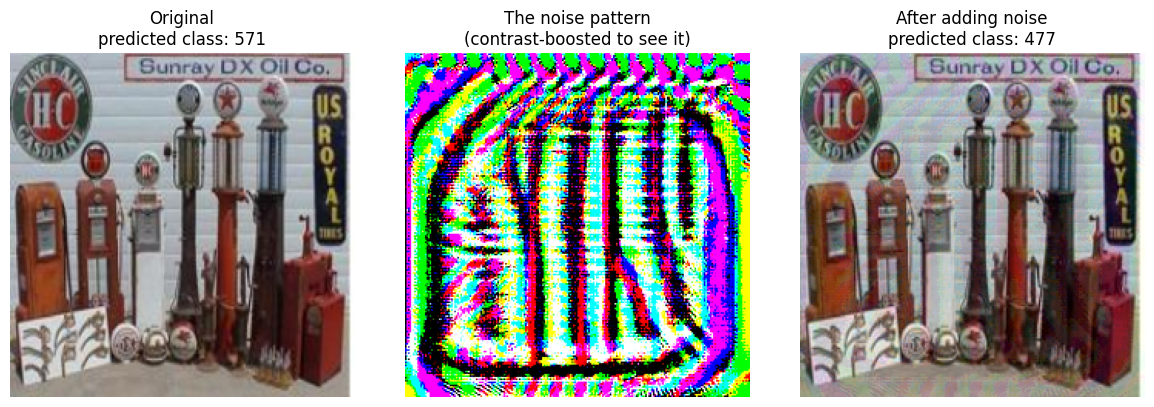

In [7]:
idx = (original_preds != perturbed_preds).nonzero()[0].item()  # find one image that got fooled

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_images[idx].permute(1, 2, 0).cpu().numpy())
axes[0].set_title(f'Original\npredicted class: {original_preds[idx].item()}')
axes[1].imshow((delta[0].permute(1, 2, 0).cpu().numpy() - delta.min().item()) / (delta.max().item() - delta.min().item()))
axes[1].set_title('The noise pattern\n(contrast-boosted to see it)')
axes[2].imshow(perturbed_test_images[idx].permute(1, 2, 0).cpu().numpy())
axes[2].set_title(f'After adding noise\npredicted class: {perturbed_preds[idx].item()}')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 5 - Our original contribution: does the trick survive JPEG compression?

**Why this matters:** in the real world, images almost never stay pixel-perfect. They get compressed when uploaded to social media, resized, re-saved. If the fooling noise disappears the moment an image is compressed, that's actually reassuring news for real-world AI safety. If it survives, that's a more concerning finding. Either way, it's a genuine, useful question the original paper doesn't test -- which is exactly the kind of "one small original piece" that makes a project stand out.

In [8]:
def jpeg_compress(image_tensor, quality):
    # Converts a tensor image to a real JPEG file in memory at a given quality, then loads it back.
    # This actually performs real JPEG compression, not a simulation.
    pil_img = T.ToPILImage()(image_tensor.cpu())
    buffer = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    compressed_img = Image.open(buffer).convert('RGB')
    return T.ToTensor()(compressed_img)

quality_levels = [100, 90, 75, 50, 25, 10]
fooling_rates_by_quality = []

for quality in quality_levels:
    compressed_batch = torch.stack([
        jpeg_compress(perturbed_test_images[i], quality) for i in range(len(perturbed_test_images))
    ]).to(device)

    compressed_preds = get_predictions(compressed_batch)
    rate = (original_preds != compressed_preds).float().mean().item() * 100
    fooling_rates_by_quality.append(rate)
    print(f'JPEG quality {quality}: fooling rate = {rate:.1f}%')

JPEG quality 100: fooling rate = 43.5%
JPEG quality 90: fooling rate = 40.0%
JPEG quality 75: fooling rate = 39.0%
JPEG quality 50: fooling rate = 40.0%
JPEG quality 25: fooling rate = 43.5%
JPEG quality 10: fooling rate = 56.0%


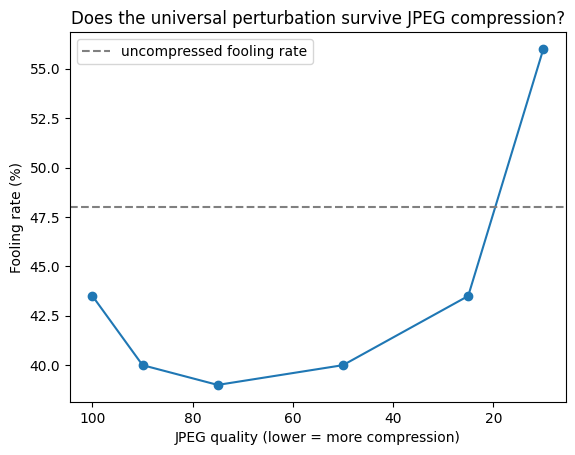

In [9]:
plt.plot(quality_levels, fooling_rates_by_quality, marker='o')
plt.gca().invert_xaxis()  # so 'more compression' reads left-to-right
plt.axhline(fooling_rate, linestyle='--', color='gray', label='uncompressed fooling rate')
plt.xlabel('JPEG quality (lower = more compression)')
plt.ylabel('Fooling rate (%)')
plt.title('Does the universal perturbation survive JPEG compression?')
plt.legend()
plt.show()